In [1]:
from pycalphad import Database, equilibrium, variables as v
import matplotlib.pyplot as plt

# 1. Load your sanitized MatCalc database
dbf = Database('../2databases/mc_fe_v2062_clean.tdb')

# 2. Updated elements list (Added CR, SI, C. Removed AL)
comps = ['FE', 'CR', 'CO', 'NI', 'TI', 'MO', 'SI', 'C', 'VA']

# 3. Fetch all phases available in the database
phases = list(dbf.phases.keys())

# 4. Set conditions matching the paper: Fe-11Cr-4Co-8Ni-0.5Ti-5Mo-0.1Si-0.002C (wt.%) at 480°C
conds = {
    v.P: 101325,          # Standard pressure (Pa)
    v.T: 753.15,          # 480°C converted to Kelvin
    v.W('CR'): 0.11,      # 11.0 wt.%
    v.W('NI'): 0.08,      # 8.0 wt.%
    v.W('MO'): 0.05,      # 5.0 wt.%
    v.W('CO'): 0.04,      # 4.0 wt.%
    v.W('TI'): 0.005,     # 0.5 wt.%
    v.W('SI'): 0.001,     # 0.1 wt.%
    v.W('C'):  0.00002    # 0.002 wt.%
    # Fe is automatically calculated as the balance
}

# 5. Run the isothermal equilibrium calculation
eq_result = equilibrium(dbf, comps, phases, conds)

# 6. Extract and display the phase fractions
print(eq_result.Phase.values)
print(eq_result.NP.values)

/home/adi/conda-envs/struct/lib/python3.11/site-packages/pycalphad/io/tdb.py:995: UserWarning: The type definition character `%` was defined in the following phases: ['LIQUID', 'FCC_A1', 'BCC_A2', 'H_BCC', 'HCP_A3', 'ALPHA_MN', 'BETA_MN', 'BETA_RHOMBO_B', 'DIAMOND_A4', 'GRAPHITE', 'BCC_B2', 'NISI', 'CHI_A12', 'CO3MO', 'CO3V', 'COV3', 'CR3MN5', 'G_PHASE', 'C15_LAVES', 'GAMMA_PRIME', 'LAVES_PHASE', 'MNNI', 'MNNI2', 'T2_MNNISI', 'T4', 'T7', 'MU_PHASE', 'MU_PHASE_I', 'NI2SIH', 'NI2SIL', 'NI3SI2', 'NI3SIH', 'NI3SIL', 'NI5SI2', 'ETA', 'NITI2', 'PI_PHASE', 'R_PHASE', 'SIGMA', 'FE17Y2', 'NI5Y', 'PDFE_L12', 'PDMN_AF', 'PDMN_P', 'PDMN_B2', 'PD2MN', 'PD3MN', 'PD5MN3', 'PD6FE5MN2', 'CEMENTITE', 'CR2VC2', 'K_CARB', 'KSI_CARBIDE', 'M3C2', 'M6C', 'M7C3', 'M12C', 'M23C6', 'MOC_ETA', 'V3C2', 'WC', 'EPS_CARB', 'ETA_CARB', 'FE24C10', 'KSI_FE5C2', 'ALN', 'ALN_EQU', 'BN_HP4', 'FE4N', 'MN6N4', 'MN6N5', 'MNSIN2', 'SI3N4', 'TAN_EPS', 'ZET', 'CRB', 'CR2B', 'CR5B3', 'FEB', 'FENBB', 'FE3NB3B4', 'M2B', 'MNB2', 'M

[[[[[[[[[[['' '' '' '' '' '' '' '' '']]]]]]]]]]]
[[[[[[[[[[[nan nan nan nan nan nan nan nan nan]]]]]]]]]]]


/tmp/ipykernel_68800/1456366945.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='best')


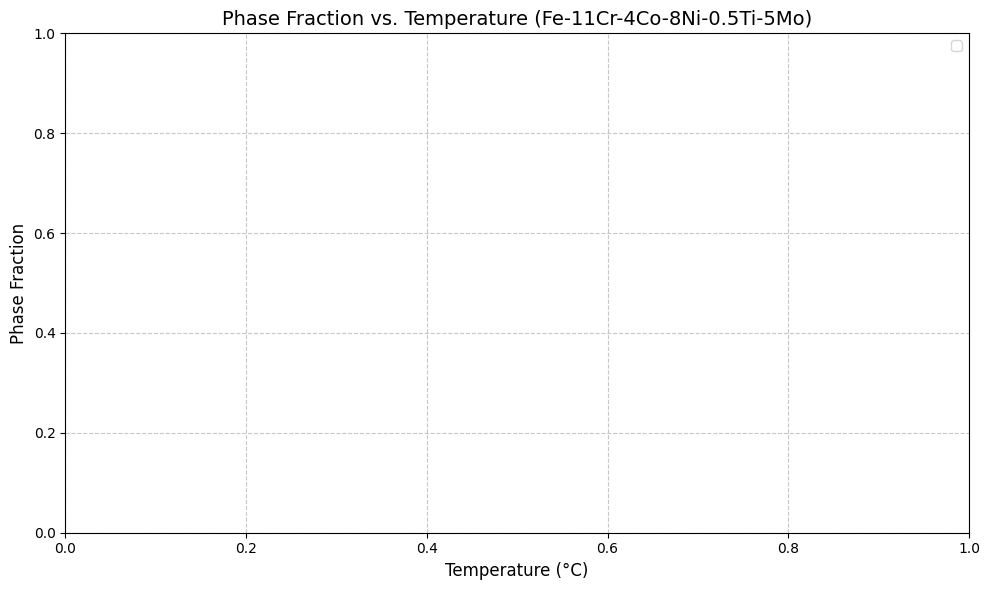

In [3]:
import numpy as np
# 5. Plotting Logic
plt.figure(figsize=(10, 6))

# Convert x-axis back to Celsius for readability
temp_celsius = eq_result.T.values - 273.15

for phase_name in phases:
    # PyCalphad stores phase fractions in the 'NP' array
    phase_frac = eq_result.NP.where(eq_result.Phase == phase_name).sum(dim='vertex').values.squeeze()
    
    # Filter out trace phases (only plot if it hits at least 1% fraction)
    if np.max(phase_frac) > 0.01:
        plt.plot(temp_celsius, phase_frac, label=phase_name, linewidth=2)

# Formatting the chart
plt.xlabel('Temperature (°C)', fontsize=12)
plt.ylabel('Phase Fraction', fontsize=12)
plt.title('Phase Fraction vs. Temperature (Fe-11Cr-4Co-8Ni-0.5Ti-5Mo)', fontsize=14)
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Render
plt.show()